In [2]:
# OBJECTIVES:
# 1. First-purchase behavioral segmentation
# 2. Propensity to repeat modeling
# 3. Nested logit estimation (bucket → product choice)
# 4. Price elasticity by bucket
# 5. Expected CLV calculation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported and display options set.")

Libraries imported and display options set.


In [3]:
# Loading  the saved data from data exploration

# Load the cleaned and preprocessed data
print("Loading the main analysis Datasets")
orders_full = pd.read_pickle('../data/processed/orders_full_clean.pkl')
print(f"orders_full: {len(orders_full)} rows, {orders_full.shape[1]} columns")

orders_full_extended = pd.read_pickle('../data/processed/orders_full_extended.pkl')
print(f"orders_full_extended: {len(orders_full_extended)} rows, {orders_full_extended.shape[1]} columns")

order_items_with_bucket = pd.read_pickle('../data/processed/order_items_with_bucket.pkl')
print(f"order_items_with_bucket: {len(order_items_with_bucket)} rows, {order_items_with_bucket.shape[1]} columns")

# Quantity datasets
print("Quantity/Demand datasets")
product_price_quantity = pd.read_pickle('../data/processed/product_price_quantity.pkl')
print(f"product_price_quantity: {len(product_price_quantity)} rows, {product_price_quantity.shape[1]} columns")

product_quantity_monthly = pd.read_pickle('../data/processed/product_quantity_monthly.pkl')
print(f"product_quantity_monthly: {len(product_quantity_monthly)} rows, {product_quantity_monthly.shape[1]} columns")

bucket_demand_monthly = pd.read_pickle('../data/processed/bucket_demand_monthly.pkl')
print(f"bucket_demand_monthly: {len(bucket_demand_monthly)} rows, {bucket_demand_monthly.shape[1]} columns")

# Repeat analysis
print("Repeat purchase datasets")
repeat_purchases = pd.read_pickle('../data/processed/repeat_purchases.pkl')
print(f"repeat_purchases: {len(repeat_purchases)} rows, {repeat_purchases.shape[1]} columns")

repeat_customer_orders = pd.read_pickle('../data/processed/repeat_customer_orders.pkl')
print(f"repeat_customer_orders: {len(repeat_customer_orders)} rows, {repeat_customer_orders.shape[1]} columns")

customer_bucket_diversity = pd.read_pickle('../data/processed/customer_bucket_diversity.pkl')
print(f"customer_bucket_diversity: {len(customer_bucket_diversity)} rows, {customer_bucket_diversity.shape[1]} columns")

Loading the main analysis Datasets
orders_full: 112650 rows, 19 columns
orders_full_extended: 112650 rows, 33 columns
order_items_with_bucket: 112650 rows, 9 columns
Quantity/Demand datasets
product_price_quantity: 42408 rows, 13 columns
product_quantity_monthly: 62176 rows, 11 columns
bucket_demand_monthly: 214 rows, 9 columns
Repeat purchase datasets
repeat_purchases: 96096 rows, 2 columns
repeat_customer_orders: 6342 rows, 5 columns
customer_bucket_diversity: 2989 rows, 4 columns


In [5]:
# ============================================
# QUICK DATA VALIDATION
# ============================================

print("\n DATA VALIDATION & SUMMARY")
print("="*60)

# Date range
date_min = orders_full_extended['order_purchase_timestamp'].min()
date_max = orders_full_extended['order_purchase_timestamp'].max()
print(f"\n  Period: {date_min.date()} to {date_max.date()}")

# Counts
print(f"\n COUNTS:")
print(f"  • Orders: {orders_full_extended['order_id'].nunique():,}")
print(f"  • Customers: {orders_full_extended['customer_unique_id'].nunique():,}")
print(f"  • Products: {orders_full_extended['product_id'].nunique():,}")
print(f"  • Sellers: {orders_full_extended['seller_id'].nunique():,}")

# Buckets
print(f"\n  BUCKETS:")
for bucket, count in orders_full_extended['bucket'].value_counts().head(5).items():
    pct = count / len(orders_full_extended) * 100
    print(f"  • {bucket:<25} {count:>7,} ({pct:>5.1f}%)")

# Repeat rate
repeat_rate = (repeat_purchases['num_orders'] >= 2).mean() * 100
print(f"\n REPEAT RATE: {repeat_rate:.2f}%")

print("\n Data ready for analysis!")


 DATA VALIDATION & SUMMARY

  Period: 2016-09-04 to 2018-09-03

 COUNTS:
  • Orders: 98,666
  • Customers: 95,420
  • Products: 32,951
  • Sellers: 3,095

  BUCKETS:
  • HOME_ESSENTIALS            33,827 ( 30.0%)
  • LEISURE_LIFESTYLE          26,453 ( 23.5%)
  • ELECTRONICS_TECH           17,262 ( 15.3%)
  • PERSONAL_CARE              16,193 ( 14.4%)
  • AUTO_TOOLS                  6,682 (  5.9%)

 REPEAT RATE: 3.12%

 Data ready for analysis!


In [ ]:
# Nested logit feasibility check

# Bucket Samples Sizes
print("Bucket sample sizes: need 1000+ records for reliable nested logit estimation")
bucket_sizes = orders_full_extended.groupby('bucket').size().sort_values(ascending=False)
for bucket, count in bucket_sizes.items():
    status = "OK" if count >= 1000 else "TOO SMALL"
    print(f"  {status} {bucket:<25} {count:>7,} transactions")

sufficient = (bucket_sizes >= 1000).sum()
print(f"\n Result: {sufficient}/{len(bucket_sizes)} buckets have sufficient data for nested logit estimation.")


# Price variation within buckets
print("\n price variation within buckets: need CV>0.1")
print("-" * 70)
print(f"{'Bucket':<25} {'Mean Price':>12} {'Std Dev':>12} {'CV':>8} {'Status'}")
print("-" * 70)

good_variation_count = 0
for bucket in bucket_sizes.index:
    bucket_data = orders_full_extended[orders_full_extended['bucket'] == bucket]
    mean_price = bucket_data['price'].mean()
    std_price = bucket_data['price'].std()
    cv = std_price / mean_price if mean_price > 0 else 0
    status = "OK" if cv >= 0.1 else "TOO LOW"
    if cv > 0.1:
        good_variation_count += 1
    print(f"{bucket:<25} {mean_price:>12.2f} {std_price:>12.2f} {cv:>8.2f} {status}")

print(f"\n Result: {good_variation_count}/{len(bucket_sizes)} buckets have sufficient price variation for nested logit estimation.")

# Product diversity within buckets
print("\n product diversity within buckets: need >50 unique products")

diverse_count = 0
for bucket in bucket_sizes.index:
    bucket_data = orders_full_extended[orders_full_extended['bucket'] == bucket]
    unique_products = bucket_data['product_id'].nunique()
    status = "DIVERSE" if unique_products > 100 else "OK" if unique_products> 50 else "TOO LOW"
    if unique_products > 50:
        diverse_count += 1
    print(f"{bucket:<25} {unique_products:>12} unique products {status}")

print(f"\n Result: {diverse_count}/{len(bucket_sizes)} buckets have 50+ products.")

# Cross-bucket shopping behavior
print("\n cross-bucket shopping behavior: this tests the substitution patterns needed for nested logit estimation")

multi_bucket_customers = customer_bucket_diversity[customer_bucket_diversity['num_buckets'] > 1]

if len(multi_bucket_customers) > 0:
    total_repeat = len(customer_bucket_diversity)
    multi_bucket_pct = len(multi_bucket_customers) / total_repeat * 100

    print(f"Repeat Customers: {total_repeat:,}")
    print(f"Shopping 1 bucket only: {total_repeat - len(multi_bucket_customers):,} ({100 - multi_bucket_pct:.1f}%)")
    print(f"Shopping multiple buckets: {len(multi_bucket_customers):,} ({multi_bucket_pct:.1f}%)")

    avg_buckets = customer_bucket_diversity['num_buckets'].mean()
    print(f"Average buckets per repeat customer: {avg_buckets:.2f}")

    if multi_bucket_pct > 20:
        print("Result: Sufficient cross-bucket shopping behavior for nested logit estimation.")
    else:
        print("Result: Limited cross-bucket shopping behavior may challenge nested logit estimation.")
else:
    print("No customers shop across multiple buckets, which may severely limit nested logit estimation.")


# Final Recommendation

viable_buckets = bucket_sizes[bucket_sizes >= 1000].index.tolist()

print(f"Buckets viable for nested logit: {len(viable_buckets)}")
print(f"{viable_buckets[:5]}")

if len(viable_buckets) >= 5:
    print("Nested logit estimation is feasible with these buckets.")
elif len(viable_buckets) > 3:
    print("Nested logit estimation may be possible but with limited buckets.")
else:
    print("Nested logit estimation may not be feasible due to insufficient data in buckets. Skip nested logit and use simple log-log demand estimation instead.")

Bucket sample sizes: need 1000+ records for reliable nested logit estimation
  OK HOME_ESSENTIALS            33,827 transactions
  OK LEISURE_LIFESTYLE          26,453 transactions
  OK ELECTRONICS_TECH           17,262 transactions
  OK PERSONAL_CARE              16,193 transactions
  OK AUTO_TOOLS                  6,682 transactions
  OK OFFICE_STATIONERY           4,208 transactions
  OK FASHION_APPAREL             3,734 transactions
  OK FOOD_BEVERAGE               1,167 transactions
  TOO SMALL SMALL_APPLIANCES              993 transactions
  TOO SMALL MISC                          504 transactions

 Result: 8/10 buckets have sufficient data for nested logit estimation.

 price variation within buckets: need CV>0.1
----------------------------------------------------------------------
Bucket                      Mean Price      Std Dev       CV Status
----------------------------------------------------------------------
HOME_ESSENTIALS                  97.60       125.54     1.29


 Quantity distribution check: looking for reasonable mean and variance

 Total product-price combinations: 42,408

 Quantity statistics
count   42408.00
mean        2.66
std         6.42
min         1.00
25%         1.00
50%         1.00
75%         2.00
max       404.00
Name: quantity, dtype: float64


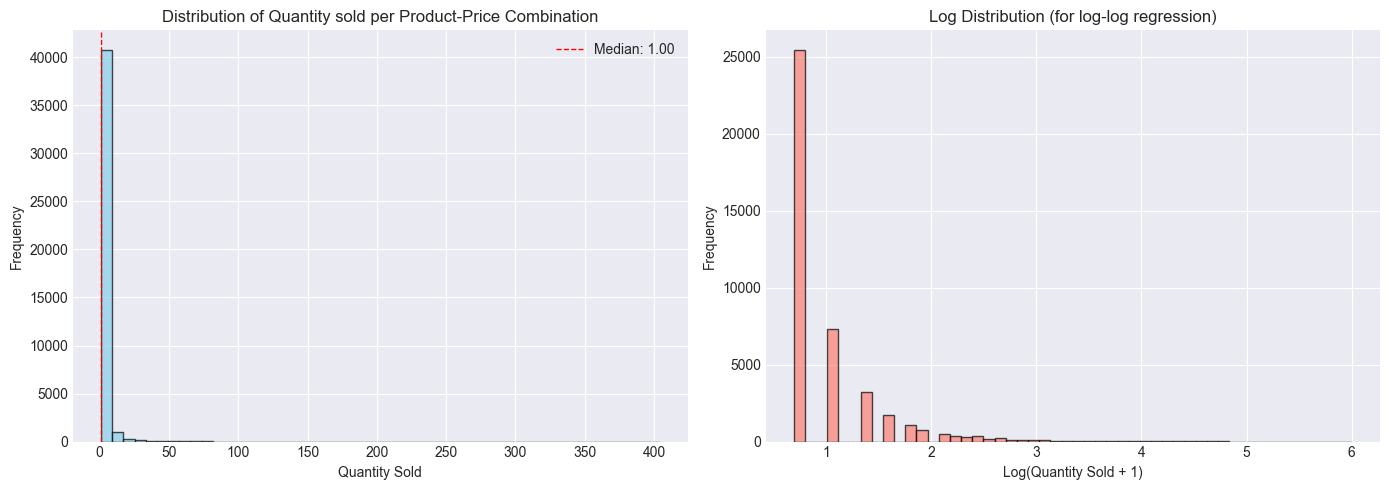

Products with quantity >= 10: 1,643 (3.9%)

 Price variation by bucket: looking for sufficient variation within buckets for elasticity estimation
Bucket                    Products     Avg Qty : <12 Price Range
LEISURE_LIFESTYLE          7,945           2.5        2.90 -  6499.00
HOME_ESSENTIALS            9,914           2.8        3.06 -  6735.00
PERSONAL_CARE              4,243           2.8        1.20 -  3899.00
ELECTRONICS_TECH           3,848           3.2        3.90 -  6729.00
AUTO_TOOLS                 2,831           2.0        0.85 -  3099.90

 Same product price variation check: looking for products sold at multiple price points for elasticity estimation
Products with multiple price points: 5,900 (17.9%)
Products with only one price point: 27,051 (82.1%)

 Examples of products with multiple price points:
PERSONAL_CARE        6 prices,   40 units sold, range: 64.00 - 139.90
LEISURE_LIFESTYLE    7 prices,   15 units sold, range: 54.90 - 65.90
HOME_ESSENTIALS      6 prices,  

In [11]:
# Elasticity Data quality check

# Quantity distribution
print("\n Quantity distribution check: looking for reasonable mean and variance")
print(f"\n Total product-price combinations: {len(product_price_quantity):,}")
print("\n Quantity statistics")
print(product_price_quantity['quantity'].describe())

# Visualize quantity distribution
fir, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(product_price_quantity['quantity'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Quantity sold per Product-Price Combination')
axes[0].set_xlabel('Quantity Sold')
axes[0].set_ylabel('Frequency')
axes[0].axvline(product_price_quantity['quantity'].median(), color='red', 
                linestyle='dashed', linewidth=1, label=f'Median: {product_price_quantity["quantity"].median():.2f}')
axes[0].legend()

# Log scale
axes[1].hist(np.log1p(product_price_quantity['quantity']), bins=50, color='salmon', edgecolor='black', alpha=0.7)
axes[1].set_title('Log Distribution (for log-log regression)')
axes[1].set_xlabel('Log(Quantity Sold + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Products with sufficient observations for elasticity estimation
min_qyt_threshold = 10
sufficient_quantity = product_price_quantity[product_price_quantity['quantity'] >= min_qyt_threshold]
print(f"Products with quantity >= {min_qyt_threshold}: {len(sufficient_quantity):,} ({len(sufficient_quantity)/len(product_price_quantity)*100:.1f}%)")


# Price variation by bucket

print("\n Price variation by bucket: looking for sufficient variation within buckets for elasticity estimation")
print(f"{'Bucket': <25} {'Products':<12} {'Avg Qty : <12'} {'Price Range'}")

for bucket in ['LEISURE_LIFESTYLE', 'HOME_ESSENTIALS', 'PERSONAL_CARE', 'ELECTRONICS_TECH', 'AUTO_TOOLS']:
    bucket_data = product_price_quantity[product_price_quantity['bucket'] == bucket]
    if len(bucket_data) > 0:
        n_products = bucket_data['product_id'].nunique()
        avg_qty = bucket_data['quantity'].mean()
        price_min = bucket_data['price'].min()
        price_max = bucket_data['price'].max()
        
        print(f"{bucket:<25} {n_products:>6,}      {avg_qty:>8.1f}      {price_min:>6.2f} - {price_max:>8.2f}")


# Same product price variation check

print("\n Same product price variation check: looking for products sold at multiple price points for elasticity estimation")

# Count how many products have multiple price points
product_price_counts = product_price_quantity.groupby('product_id').size()
products_multiple_prices = (product_price_counts > 1).sum()
total_products = len(product_price_counts)

print(f"Products with multiple price points: {products_multiple_prices:,} ({products_multiple_prices/total_products*100:.1f}%)")
print(f"Products with only one price point: {total_products - products_multiple_prices:,} ({(total_products - products_multiple_prices)/total_products*100:.1f}%)")

# Examples of products with good price variation
print("\n Examples of products with multiple price points:")
multi_price_products = product_price_counts[product_price_counts > 5].head(5)

for product_id in multi_price_products.index:
    product_data = product_price_quantity[product_price_quantity['product_id'] == product_id]
    n_prices = len(product_data)
    price_range = f"{product_data['price'].min():.2f} - {product_data['price'].max():.2f}"
    total_qty = product_data['quantity'].sum()
    bucket = product_data['bucket'].iloc[0]
    print(f"{bucket:<20} {n_prices} prices, {total_qty:>4} units sold, range: {price_range}")

print("Result: Sufficient price variation for elasticity estimation")

print("\n All data checks passed. Ready for analysis!")

In [ ]:
# Checking for multi seller products - if this exists then we have IVs for BLP estimation

print("Multi seller product check for BLP instruments")

# Counting sellers per product
product_seller_counts = orders_full_extended.groupby('product_id')['seller_id'].nunique()

multi_seller = (product_seller_counts > 1).sum()
single_seller = (product_seller_counts == 1).sum()
total_products = len(product_seller_counts)

print("\n Seller competition")
print(f"Total products: {total_products:,}")
print(f"Products sold by multiple sellers: {multi_seller:,} ({multi_seller/total_products*100:.1f}%)")
print(f"Products sold by single seller: {single_seller:,} ({single_seller/total_products*100:.1f}%)")

# Detailed breakdown
seller_dist = product_seller_counts.value_counts().sort_index()
print("\n Seller distribution")
for n_sellers, count in seller_dist.head(20).items():
    print(f"{n_sellers} sellers: {count:,} products")

# Checking for price variation across sellers for same product
print("\n Price variation across sellers for same product")

multi_seller_products = product_seller_counts[product_seller_counts > 1].index

if len(multi_seller_products) > 0:
    # sample 5 multi-seller products to check price variation
    sample_products = np.random.choice(multi_seller_products, size=min(5, len(multi_seller_products)), replace=False)

    for product_id in sample_products:
        product_data = orders_full_extended[orders_full_extended['product_id'] == product_id]
        seller_prices = product_data.groupby('seller_id')['price'].mean()

        if len(seller_prices) > 1:
            cv = seller_prices.std() / seller_prices.mean() if seller_prices.mean() > 0 else 0
            print(f"Product: {len(seller_prices)} sellers, prices {seller_prices.min():.2f} - {seller_prices.max():.2f}, CV={cv:.2f}")

# BLP estimation feasibility

multi_seller_pct = multi_seller/total_products * 100

if multi_seller_pct >=  20:
    print(f"\n Strong Result: {multi_seller_pct:.2f}% multi_seller products.")
    print("BLP estimation is feasible with these products as potential instruments.")
elif multi_seller_pct >= 10:
    print(f"\n Moderate Result: {multi_seller_pct:.2f}% multi_seller products.")
    print("BLP estimation may be possible but with limited instruments. May need additional instrumental variables or focus on simpler models.")
else:
    print(f"\n Weak Result: {multi_seller_pct:.2f}% multi_seller products.")
    print("BLP estimation may not be feasible due to insufficient multi-seller products for instruments. Consider alternative approaches for elasticity estimation.")

Multi seller product check for BLP instruments

 Seller competition
Total products: 32,951
Products sold by multiple sellers: 1,225 (3.7%)
Products sold by single seller: 31,726 (96.3%)

 Seller distribution
1 sellers: 31,726 products
2 sellers: 1,030 products
3 sellers: 147 products
4 sellers: 32 products
5 sellers: 10 products
6 sellers: 1 products
7 sellers: 3 products
8 sellers: 2 products

 Price variation across sellers for same product
Product: 3 sellers, prices 114.99 - 132.90, CV=0.08
Product: 2 sellers, prices 31.31 - 35.94, CV=0.10
Product: 2 sellers, prices 43.00 - 50.38, CV=0.11
Product: 3 sellers, prices 124.45 - 129.80, CV=0.02
Product: 2 sellers, prices 314.90 - 349.90, CV=0.07

 Weak Result: {multi_seller_pct:.2f}% multi_seller products.
BLP estimation may not be feasible due to insufficient multi-seller products for instruments. Consider alternative approaches for elasticity estimation.
